# Lecture 20 - (07/05/2026)

Today's Topics:

- Bayesian Classification
- Myer Briggs Analysis

## Bayesian Classification

Naive Bayes models are a group of extremely fast and simple classification algorithms that are often suitable for very high-dimensional datasets.

Because they are so fast and have so few tunable parameters, they end up being useful as a quick-and-dirty baseline for a classification problem.

These classifiers depend on Bayes Theorem which lets us model the relationship of conditional probabilities of statistical quantaties.

$$
P(L~|~{\rm features}) = \frac{P({\rm features}~|~L)P(L)}{P({\rm features})}
$$

In Bayesian classification, we're interested in finding the probability of a label $L$ given some observed features, which we can write as $P(L~|~{\rm features})$.

If we are trying to decide between two labels—let's call them $L_1$ and $L_2$—then one way to make this decision is to compute the ratio of the posterior probabilities for each label:

$$
\frac{P(L_1~|~{\rm features})}{P(L_2~|~{\rm features})} = \frac{P({\rm features}~|~L_1)}{P({\rm features}~|~L_2)}\frac{P(L_1)}{P(L_2)}
$$

All we need now is some model by which we can compute $P({\rm features}~|~L_i)$ for each label.
Such a model is called a *generative model* because it specifies the hypothetical random process that generates the data.
Specifying this generative model for each label is the main piece of the training of such a Bayesian classifier.

The general version of this straining step is normally very complex, but if we make some key assumptions about the model it can be very simple! We can find a rough approximation of the generative model for each class, and then proceed with the Bayesian classification.



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Gaussian Naive Bayes

Perhaps the easiest naive Bayes classifier to understand is Gaussian naive Bayes.
With this classifier, the assumption is that *data from each label is drawn from a simple Gaussian distribution*.
Imagine that we have the following data:

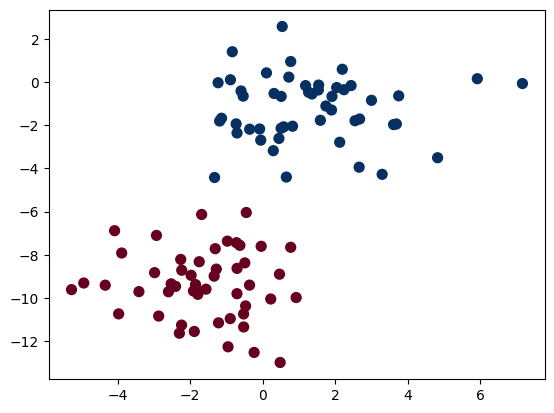

In [5]:
from sklearn.datasets import make_blobs
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu');

The simplest Gaussian model is to assume that the data is described by a Gaussian distribution with no covariance between dimensions.
This model can be fit by computing the mean and standard deviation of the points within each label, which is all we need to define such a distribution.
The result of this naive Gaussian assumption is:

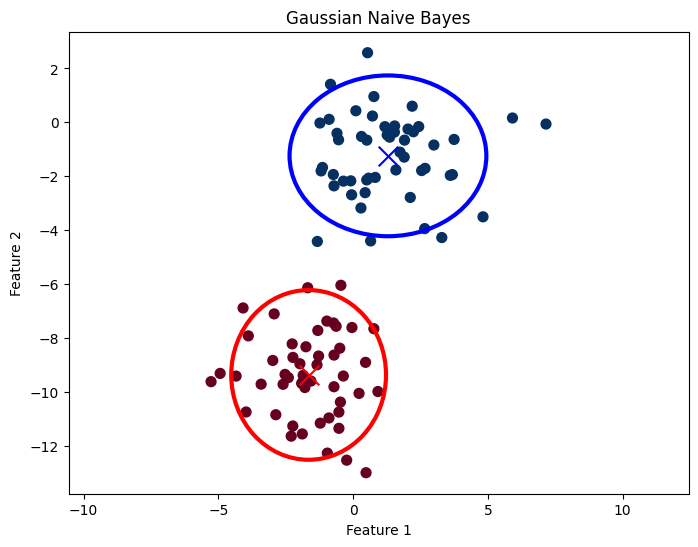

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.naive_bayes import GaussianNB
from matplotlib.patches import Ellipse

# Generate data
X, y = make_blobs(
    n_samples=100,
    n_features=2,
    centers=2,
    random_state=2,
    cluster_std=1.5
)

# Fit Gaussian Naive Bayes
model = GaussianNB()
model.fit(X, y)

# Plot points
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')

# Draw Gaussian ellipses
colors = ['red', 'blue']

for i, color in enumerate(colors):
    mean = model.theta_[i]          # class mean
    var = model.var_[i]             # class variance (diagonal covariance)

    # Width and height from variance
    width = 2 * np.sqrt(var[0]) * 2
    height = 2 * np.sqrt(var[1]) * 2

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=0,                    # Naive Bayes assumes no covariance
        edgecolor=color,
        facecolor='none',
        linewidth=3
    )

    plt.gca().add_patch(ellipse)

    # Mark class center
    plt.scatter(mean[0], mean[1], c=color, s=200, marker='x')

plt.title("Gaussian Naive Bayes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('equal')
plt.show()

The ellipses here represent the Gaussian generative model for each label, with larger probability toward the center of the ellipses.
With this generative model in place for each class, we have a simple recipe to compute the likelihood $P({\rm features}~|~L_1)$ for any data point, and thus we can quickly compute the posterior ratio and determine which label is the most probable for a given point.

This procedure is implemented in Scikit-Learn's `sklearn.naive_bayes.GaussianNB` estimator:

In [8]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X, y);

Let's generate some new data and predict the label:


In [9]:
rng = np.random.RandomState(0)
Xnew = [-6, -14] + [14, 18] * rng.rand(2000, 2)
ynew = model.predict(Xnew)

Now we can plot this new data to get an idea of where the decision boundary is (see the following figure):

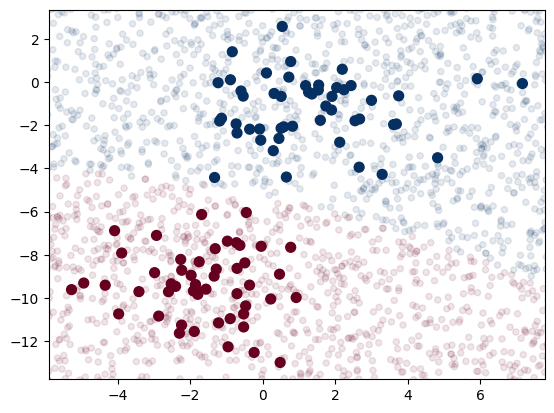

In [10]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
lim = plt.axis()
plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew, s=20, cmap='RdBu', alpha=0.1)
plt.axis(lim);

A nice aspect of this Bayesian formalism is that it naturally allows for probabilistic classification, which we can compute using the `predict_proba` method:

In [11]:
yprob = model.predict_proba(Xnew)
yprob[-8:].round(2)

array([[0.89, 0.11],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.15, 0.85]])

The columns give the posterior probabilities of the first and second labels, respectively.
If you are looking for estimates of uncertainty in your classification, Bayesian approaches like this can be a good place to start.

Of course, the final classification will only be as good as the model assumptions that lead to it, which is why Gaussian naive Bayes often does not produce very good results.
Still, in many cases—especially as the number of features becomes large—this assumption is not detrimental enough to prevent Gaussian naive Bayes from being a reliable method.

### Multinomial Naive Bayes

The Gaussian assumption just described is by no means the only simple assumption that could be used to specify the generative distribution for each label.
Another useful example is multinomial naive Bayes, where the features are assumed to be generated from a simple multinomial distribution.
The multinomial distribution describes the probability of observing counts among a number of categories, and thus multinomial naive Bayes is most appropriate for features that represent counts or count rates.

The idea is precisely the same as before, except that instead of modeling the data distribution with the best-fit Gaussian, we model it with a best-fit multinomial distribution.

One place where multinomial naive Bayes is often used is in text classification, where the features are related to word counts or frequencies within the documents to be classified.

Let's download the data and take a look at the target names:

In [12]:
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups()
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

For simplicity here, we will select just a few of these categories and download the training and testing sets:

In [13]:
categories = ['talk.religion.misc', 'soc.religion.christian',
              'sci.space', 'comp.graphics']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

Here is a representative entry from the data:

In [14]:
print(train.data[5][48:])

Subject: Federal Hearing
Originator: dmcgee@uluhe
Organization: School of Ocean and Earth Science and Technology
Distribution: usa
Lines: 10


Fact or rumor....?  Madalyn Murray O'Hare an atheist who eliminated the
use of the bible reading and prayer in public schools 15 years ago is now
going to appear before the FCC with a petition to stop the reading of the
Gospel on the airways of America.  And she is also campaigning to remove
Christmas programs, songs, etc from the public schools.  If it is true
then mail to Federal Communications Commission 1919 H Street Washington DC
20054 expressing your opposition to her request.  Reference Petition number

2493.



In order to use this data for machine learning, we need to be able to convert the content of each string into a vector of numbers.

For this we will use the TF-IDF vectorizer and create a pipeline that attaches it to a multinomial naive Bayes classifier:

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

model = make_pipeline(TfidfVectorizer(), MultinomialNB())

With this pipeline, we can apply the model to the training data and predict labels for the test data:

In [16]:
model.fit(train.data, train.target)
labels = model.predict(test.data)

Now that we have predicted the labels for the test data, we can evaluate them to learn about the performance of the estimator.
For example, let's take a look at the confusion matrix between the true and predicted labels for the test data (see the following figure):

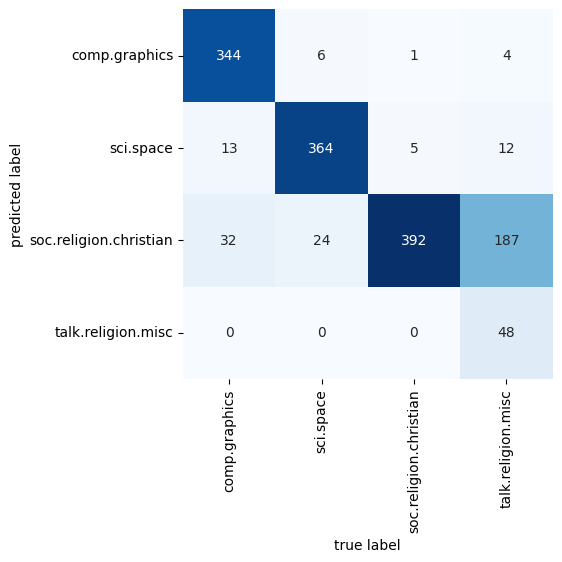

In [17]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names, yticklabels=train.target_names,
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label');

Evidently, even this very simple classifier can successfully separate space discussions from computer discussions, but it gets confused between discussions about religion and discussions about Christianity.
This is perhaps to be expected!

The cool thing here is that we now have the tools to determine the category for *any* string, using the `predict` method of this pipeline.
Here's a utility function that will return the prediction for a single string:

In [18]:
def predict_category(s, train=train, model=model):
    pred = model.predict([s])
    return train.target_names[pred[0]]

Let's try it out:

In [19]:
predict_category('sending a payload to the ISS')

'sci.space'

In [20]:
predict_category('discussing the existence of God')

'soc.religion.christian'

In [21]:
predict_category('determining the screen resolution')

'comp.graphics'

Remember that this is nothing more sophisticated than a simple probability model for the (weighted) *frequency* of each word in the string; nevertheless, the result is striking.
Even a very naive algorithm, when used carefully and trained on a large set of high-dimensional data, can be surprisingly effective.

### When to Use Naive Bayes

Because naive Bayes classifiers make such stringent assumptions about data, they will generally not perform as well as more complicated models.
That said, they have several advantages:

- They are fast for both training and prediction.
- They provide straightforward probabilistic prediction.
- They are often easily interpretable.
- They have few (if any) tunable parameters.

These advantages mean a naive Bayes classifier is often a good choice as an initial baseline classification.
If it performs suitably, then congratulations: you have a very fast, very interpretable classifier for your problem.
If it does not perform well, then you can begin exploring more sophisticated models, with some baseline knowledge of how well they should perform.

Naive Bayes classifiers tend to perform especially well in the following situations:

- When the naive assumptions actually match the data (very rare in practice)
- For very well-separated categories, when model complexity is less important
- For very high-dimensional data, when model complexity is less important

The last two points seem distinct, but they actually are related: as the dimensionality of a dataset grows, it is much less likely for any two points to be found close together (after all, they must be close in *every single dimension* to be close overall).
This means that clusters in high dimensions tend to be more separated, on average, than clusters in low dimensions, assuming the new dimensions actually add information.
For this reason, simplistic classifiers like the ones discussed here tend to work as well or better than more complicated classifiers as the dimensionality grows: once you have enough data, even a simple model can be very powerful.

## Myer Briggs Analysis

With Native Bayes down, let's try to use it!

![image](https://www.truity.com/assets/19ca0c1a-f3a7-4b89-bbaa-8a4c5e51acc3.png?width=1152&height=980)

The Myers Briggs Type Indicator (or MBTI for short) is a personality type system that divides everyone into 16 distinct personality types across 4 axis:

    Introversion (I) – Extroversion (E)
    Intuition (N) – Sensing (S)
    Thinking (T) – Feeling (F)
    Judging (J) – Perceiving (P)

So for example, someone who prefers introversion, intuition, thinking and perceiving would be labelled an INTP in the MBTI system, and there are lots of personality based components that would model or describe this person’s preferences or behaviour based on the label.

It is one of, if not the, the most popular personality test in the world. It is used in businesses, online, for fun, for research and lots more. A simple google search reveals all of the different ways the test has been used over time. It’s safe to say that this test is still very relevant in the world in terms of its use.

Let's use Native Bayes to make a classifier for MBTI Personality Types using this [data](https://www.kaggle.com/datasets/datasnaek/mbti-type?resource=download)

In [32]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from tqdm import tqdm
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC,LinearSVC
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
import plotly.express as px
from pprint import pprint
import warnings
warnings.filterwarnings('ignore')

In [27]:
data=pd.read_csv('mbti_1.csv')
data.head()

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [29]:
data['type'].value_counts()

type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64

In [30]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   type    8675 non-null   str  
 1   posts   8675 non-null   str  
dtypes: str(2)
memory usage: 135.7 KB


In [33]:
pprint(data.posts[0])

("'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp "
 'and intj moments  https://www.youtube.com/watch?v=iz7lE1g4XM4  sportscenter '
 'not top ten plays  https://www.youtube.com/watch?v=uCdfze1etec  '
 'pranks|||What has been the most life-changing experience in your '
 'life?|||http://www.youtube.com/watch?v=vXZeYwwRDw8   '
 'http://www.youtube.com/watch?v=u8ejam5DP3E  On repeat for most of '
 'today.|||May the PerC Experience immerse you.|||The last thing my INFJ '
 'friend posted on his facebook before committing suicide the next day. Rest '
 'in peace~   http://vimeo.com/22842206|||Hello ENFJ7. Sorry to hear of your '
 "distress. It's only natural for a relationship to not be perfection all the "
 'time in every moment of existence. Try to figure the hard times as times of '
 'growth, as...|||84389  84390  '
 'http://wallpaperpassion.com/upload/23700/friendship-boy-and-girl-wallpaper.jpg  '
 'http://assets.dornob.com

From above it is quite evident that there are many links in the text data. That needed to be removed.

In [34]:
train_data,test_data=train_test_split(data,test_size=0.2,random_state=42,stratify=data.type)

In [35]:
def clear_text(data):
    data_length=[]
    lemmatizer=WordNetLemmatizer()
    cleaned_text=[]
    for sentence in tqdm(data.posts):
        sentence=sentence.lower()
        
    # removing links from text data
        sentence=re.sub('https?://[^\s<>"]+|www\.[^\s<>"]+',' ',sentence)
    
    # removing other symbols
        sentence=re.sub('[^0-9a-z]',' ',sentence)
    
        
        data_length.append(len(sentence.split()))
        cleaned_text.append(sentence)
    return cleaned_text,data_length

In [36]:
train_data.posts,train_length=clear_text(train_data)

100%|██████████| 6940/6940 [00:03<00:00, 1985.77it/s]


In [37]:
test_data.posts,test_length=clear_text(test_data)

100%|██████████| 1735/1735 [00:00<00:00, 2021.57it/s]


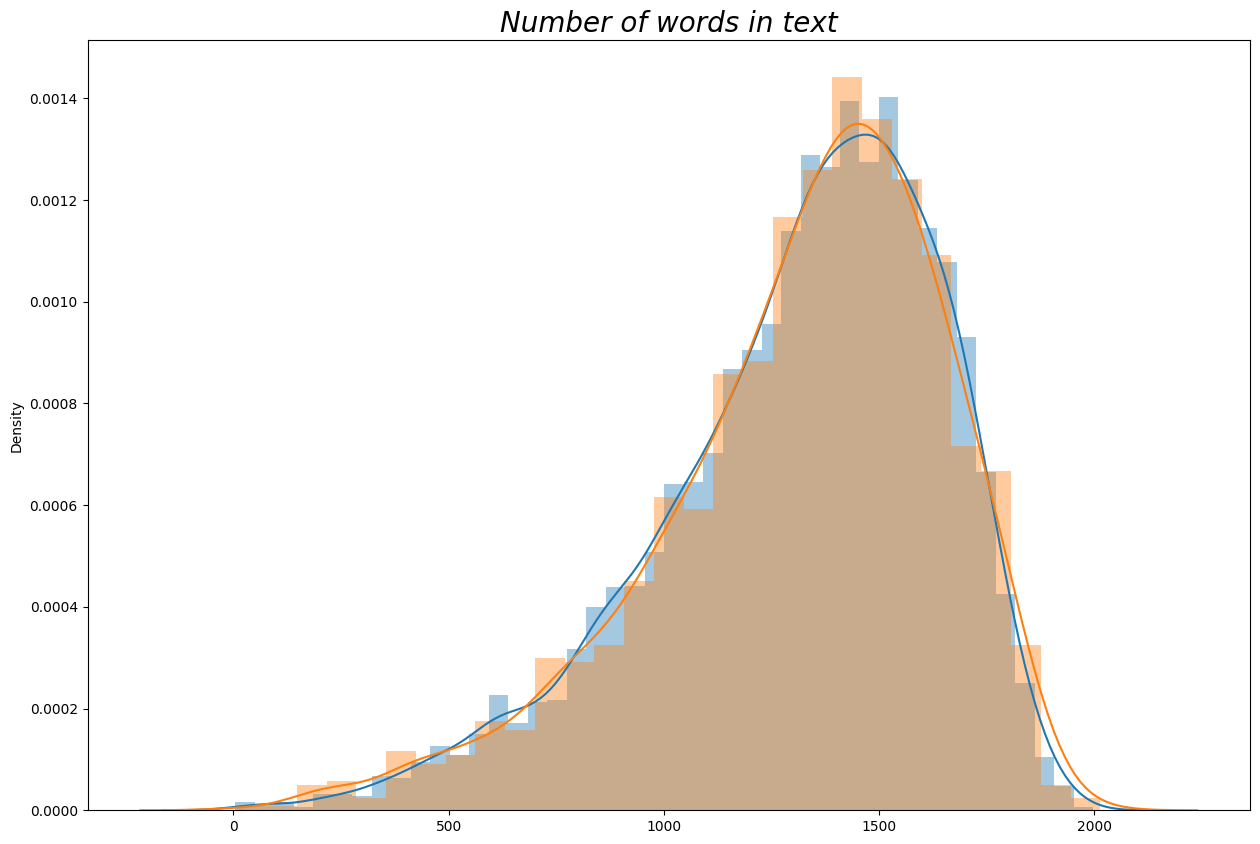

In [38]:
plt.figure(figsize=(15,10))
sns.distplot(train_length,label='train data word length')
sns.distplot(test_length,label='test data word length')
plt.title('Number of words in text',fontdict={'size':20,'style':'italic'})
plt.show()

In [39]:
px.pie(train_data,names='type',title='Personality type',hole=0.3)

In [58]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

class Lemmatizer:
    def __call__(self, doc):
        words = doc.lower().split()
        words = [
            lemmatizer.lemmatize(word)
            for word in words
            if word.isalpha() and word not in stop_words
        ]
        return words

In [60]:
vectorizer=TfidfVectorizer( max_features=5000,tokenizer=Lemmatizer())
vectorizer.fit(train_data.posts)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<__main__.Lem...t 0x1327c74d0>
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyz

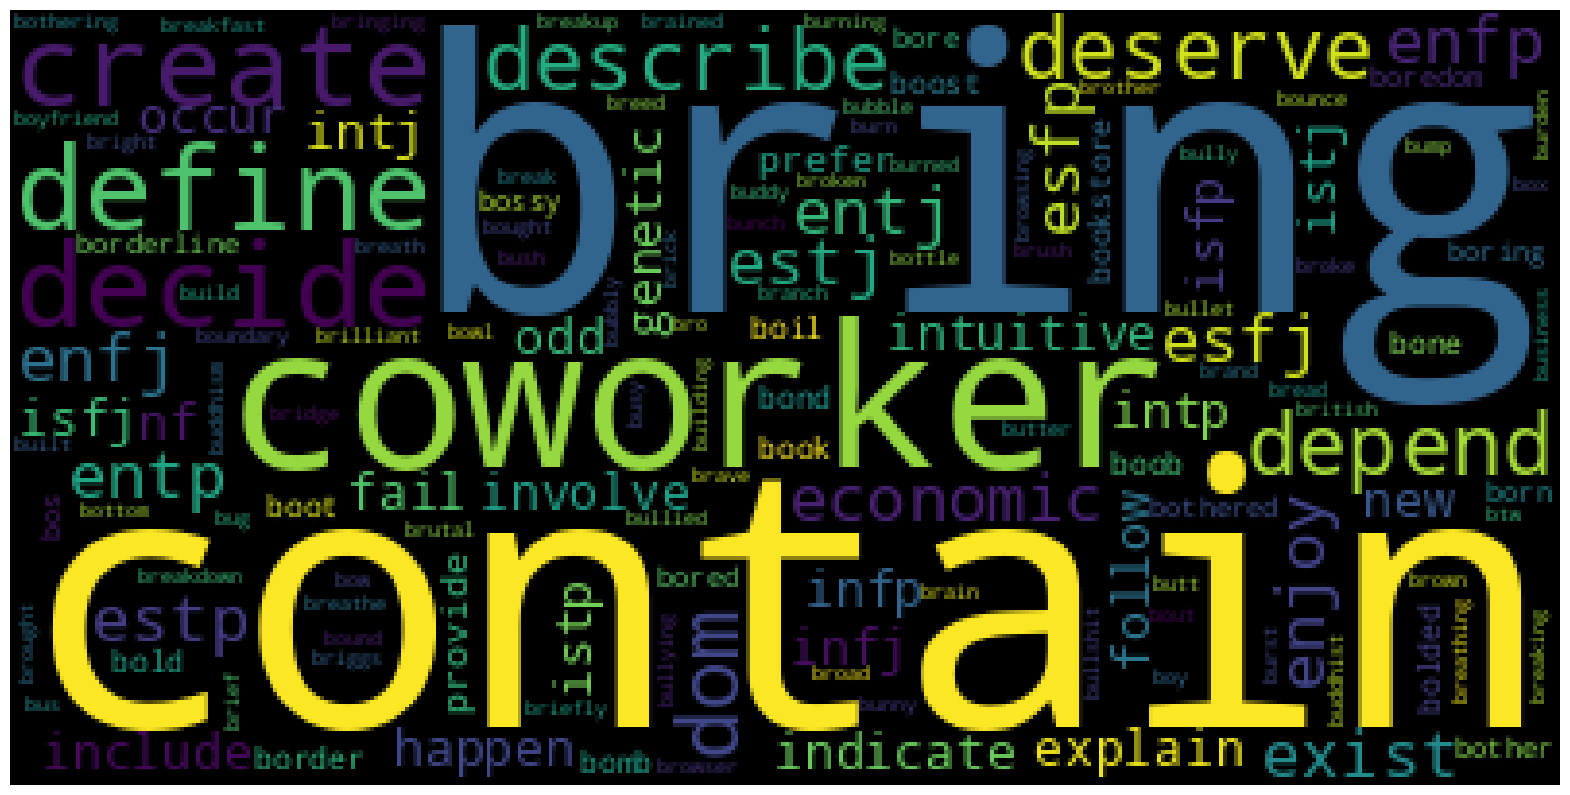

In [61]:
feature_names=vectorizer.get_feature_names_out()
wc=WordCloud(max_words=400)
wc.generate(' '.join(word for word in feature_names[500:3500] ))
plt.figure(figsize=(20,15))
plt.axis('off')
plt.imshow(wc)

In [62]:
train_post=vectorizer.transform(train_data.posts).toarray()
test_post=vectorizer.transform(test_data.posts).toarray()

target_encoder=LabelEncoder()
models_accuracy={}

train_target=target_encoder.fit_transform(train_data.type)
test_target=target_encoder.fit_transform(test_data.type)

In [63]:
model_multinomial_nb=MultinomialNB()
model_multinomial_nb.fit(train_post,train_target)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [64]:
print('train classification report \n ',classification_report(train_target,model_multinomial_nb.predict(train_post),target_names=target_encoder.inverse_transform([i for i in range(16)])))
print('test classification report \n ',classification_report(test_target,model_multinomial_nb.predict(test_post),target_names=target_encoder.inverse_transform([i for i in range(16)])))

train classification report 
                precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00       152
        ENFP       1.00      0.01      0.03       540
        ENTJ       0.00      0.00      0.00       185
        ENTP       0.92      0.04      0.08       548
        ESFJ       0.00      0.00      0.00        33
        ESFP       0.00      0.00      0.00        38
        ESTJ       0.00      0.00      0.00        31
        ESTP       0.00      0.00      0.00        71
        INFJ       0.50      0.61      0.55      1176
        INFP       0.35      0.94      0.51      1466
        INTJ       0.78      0.40      0.53       873
        INTP       0.59      0.63      0.61      1043
        ISFJ       0.00      0.00      0.00       133
        ISFP       0.00      0.00      0.00       217
        ISTJ       0.00      0.00      0.00       164
        ISTP       1.00      0.00      0.01       270

    accuracy                           0.45      

In [65]:
models_accuracy['Multinomial Naive Bayes']=accuracy_score(test_target,model_multinomial_nb.predict(test_post))

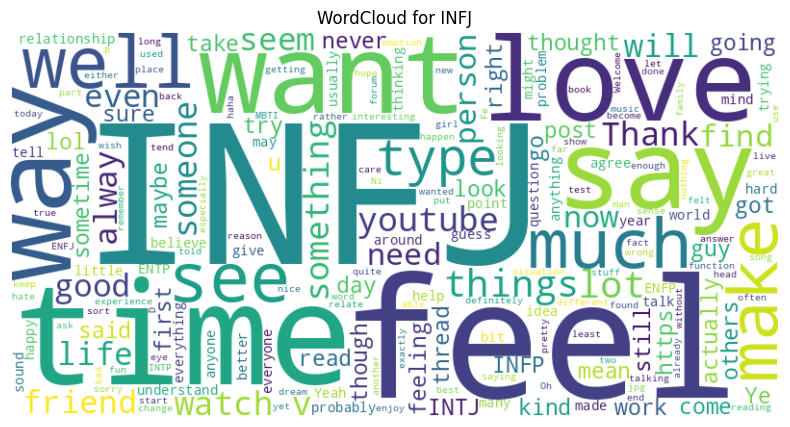

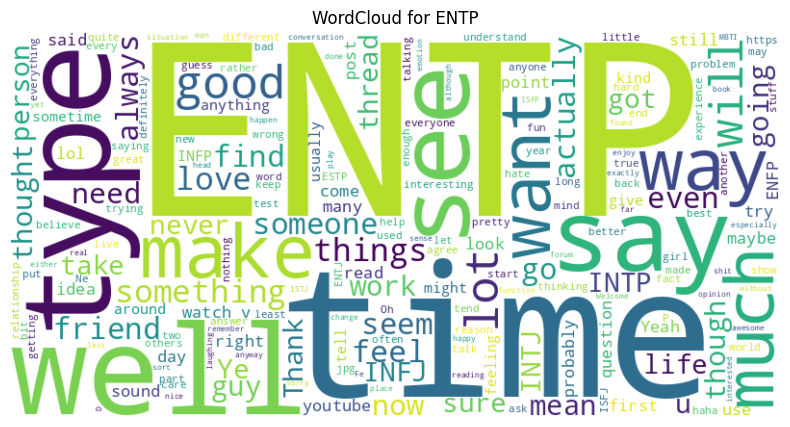

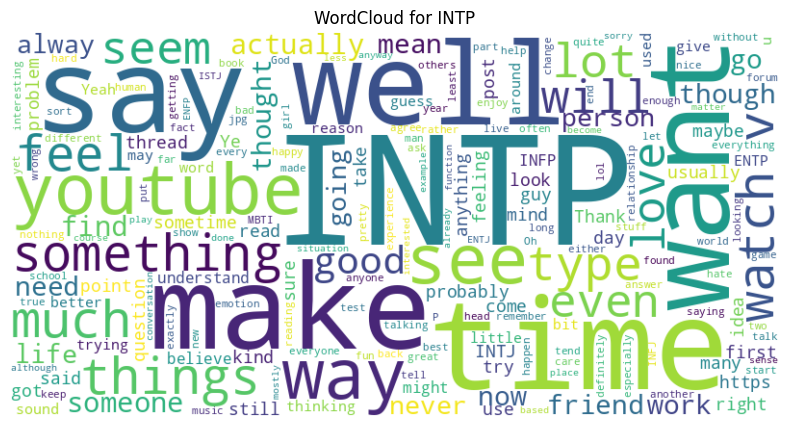

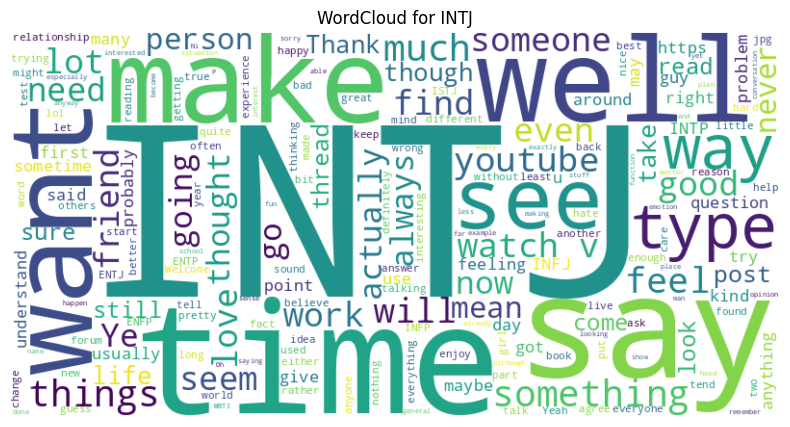

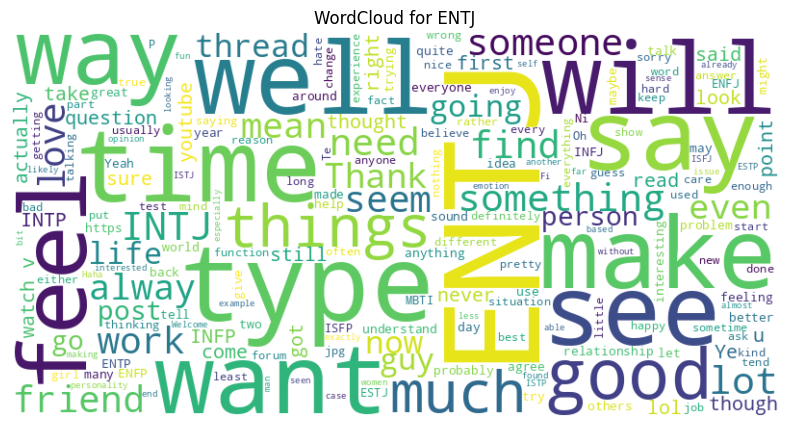

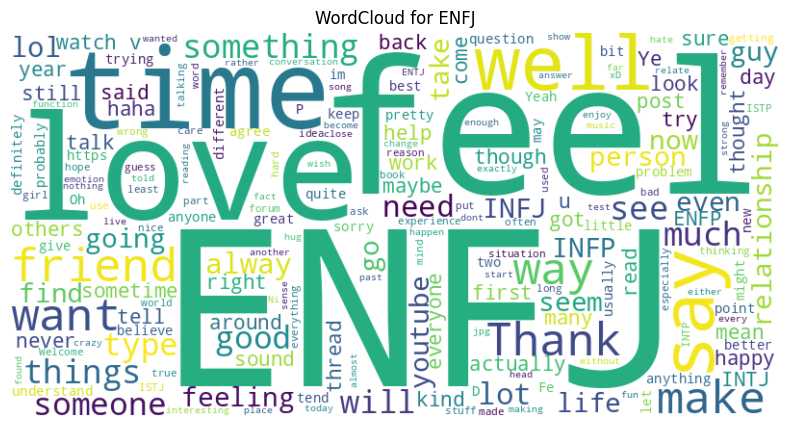

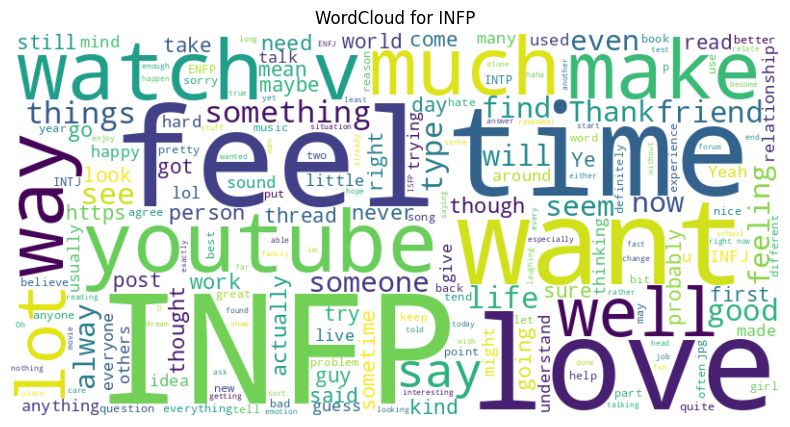

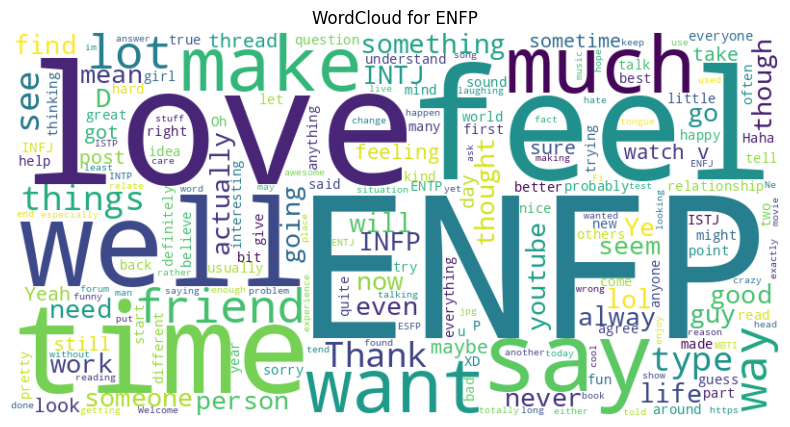

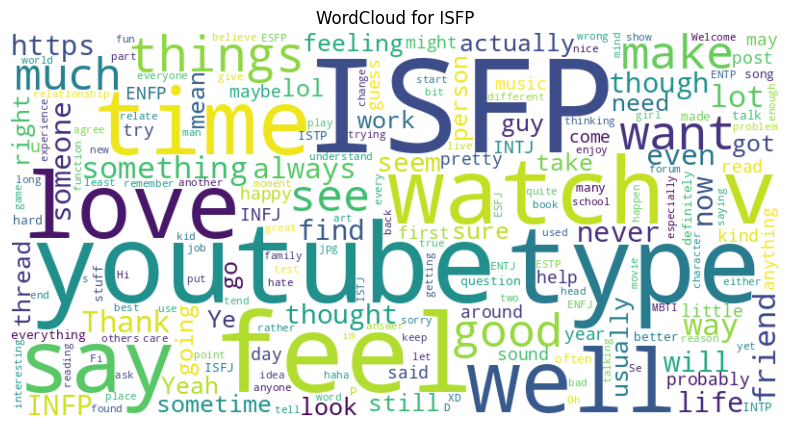

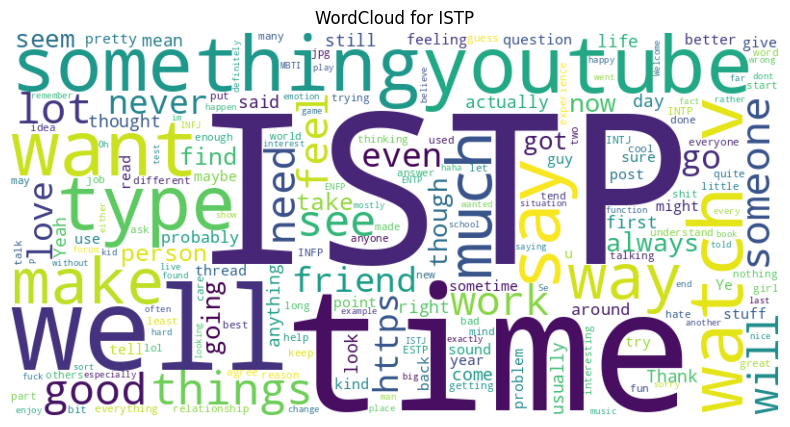

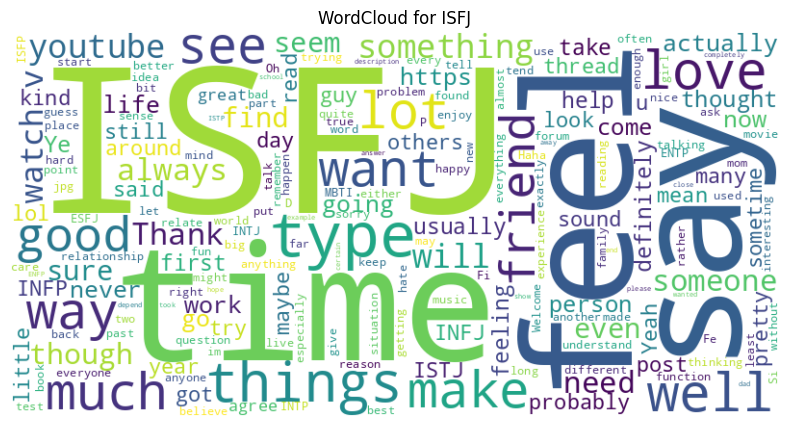

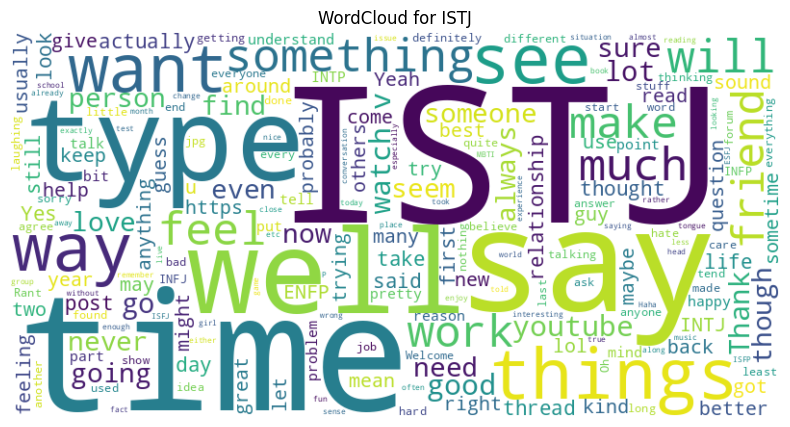

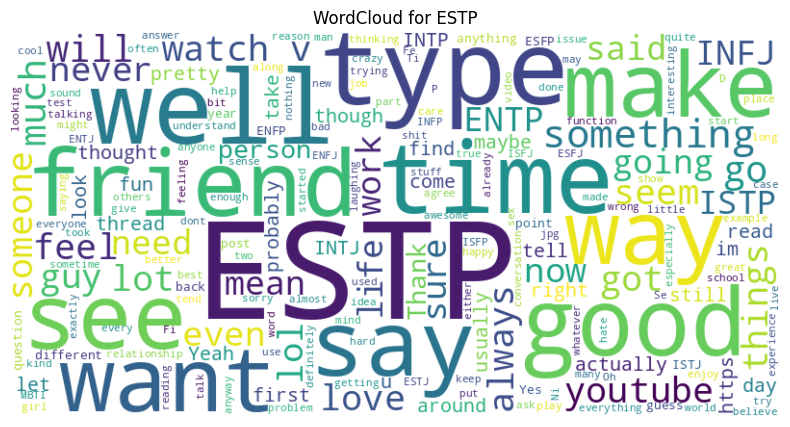

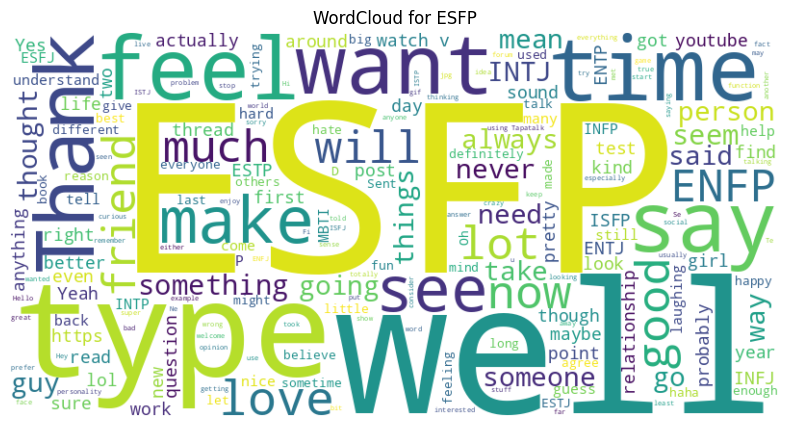

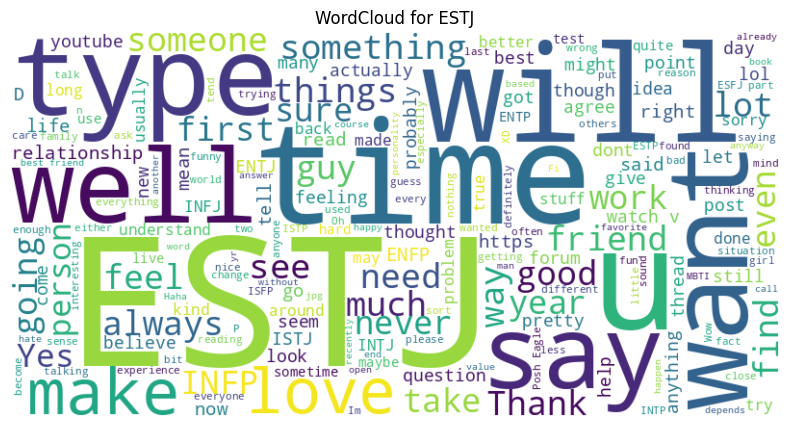

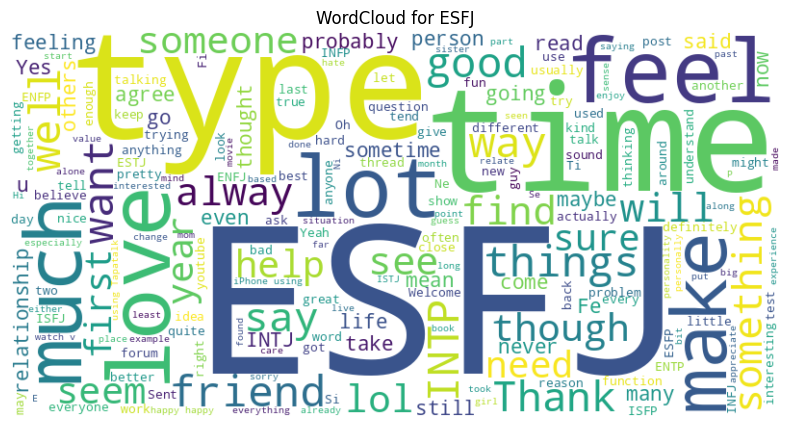

In [70]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

stop_words = set(STOPWORDS)

stop_words.update([
    'think', 'people', 'know', 'one', 'thing', 'really'
])


types = data.type.unique()

for t in types:

    text = " ".join(data[data.type == t].posts)

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stop_words
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for {t}")
    plt.show()

We can even use this model to predict the main personality types!

In [71]:
def predict_personality(text):

    # 1. vectorize input text (same vectorizer as training)
    text_vec = vectorizer.transform([text]).toarray()

    # 2. predict encoded label
    pred_encoded = model_multinomial_nb.predict(text_vec)[0]

    # 3. convert back to original label
    pred_label = target_encoder.inverse_transform([pred_encoded])[0]

    return pred_label

In [ ]:
# written by an INTP
sample_text = "Painting the world with the colors of my soul. Interpret it as you like - helping others by volunteering, teaching, giving everything you have.  Personal growth - learning as much about the universe...|||6 months ago I met this ENTP guy at my university. We are in the same group, so we basically have to be together everyday, and most likely have to study together for the next 6 years. So cutting off...|||1984 all the way|||I don't like people in groups because it's harder to enslave them.|||ESxJ or ISxJ, because I've noticed that ISxJs don't have much trouble with small talk either.  I'd say ISTJ.|||secret :)|||I really like the movie, and Alice is my alter ego in internet, since people find my real name a bit weird.|||Sense of smell easily, because my sense of smell has always been kind of weak. I think it's better that way, because I don't feel and suffer from disgusting smells people seem to feel everyday. I...|||I don't think there's a certain type who would tend to do this. I think it depends on other factors and influences throughout the person's life.|||Honey badgers|||ENFP - creative and challenging conversations. Fun to have both small talk and philosophical rambling.  ENTJ/ENFJ - adventurous friend who allows me to see things from different perspective. ENTP -...|||Please, change my username to A Clockwork Alice|||dodartt|||I'd say you're an ENFP, possibly an ESFP too.|||Completely agree with everything OP said. I am cautious around new people and usually hold my true-self inside. Because of that people assume that I am a very calm, shy, possibly even slow and...|||Less planning, more random writing. Let the words flow out of you. Try to write in start and add the characters later. Basically do the opposite of what you've done before and see what happens.|||My native language is Latvian. English is my second language, but I have become fluent enough in that. (At least I hope so). I know a little bit of Russian and German, but I have no further interest...|||Basically I ask myself questions which affect me. Those ordinary existential ones - what is the meaning of my life, what am I, where am I going, what could happen and what couldn't, what changes...|||Blind|||I like learning languages, but I'm too lazy to do it. For now, I'm fluent in English and Latvian, but forcing myself to learn Russian. I really want to learn at least one of Scandinavian languages...|||I was definitely an ENFP. Until society broke me.|||Everyday would be sunny, grass would always be green, all people would be smiling for no reason, everyone would go to church on Sundays etc. All of the earth would be just a big suburb full of sensor...|||1) Once 3) 24 h 4) I like to talk like Yoda. Also Doctor Who quotes. (Let's go poke it with a stick!) 6) I wanted to be a scientist or a writer. Hasn't changed much ever since. 7) Sometimes and I...|||In some way communication is probably one of the things that lead to intelligence. Like, for example, someone asks you a philosophical question. This triggers your mind and urges you to think about...|||Yes, this happens to me all the time. But then again, by telling the truth, you get real friends and get rid of those who can't accept you. I think it's the best way of living there is.|||I'm thinking ENTP.|||Not all of them, I bet there are Sensors who have achieved the same thing with hard work.|||Jumping out from the third floor window and breaking a few bones. I was 10 years old and spent 4 h in pain until my parents came home.  That's about it.  Now that I think about it, definitely UTI|||I see dead people|||I don't have a system. I just write down important stuff in a chaotic way, so I'm the only person who can make sense out of it later. Also idk what I'd do without photographic memory, but I'm not...|||Love both the books and the series.|||OMG SO FREAKING AWESOME. Thank you!|||The Shawshank redemption.|||I've had a similar problem, only I'm the INTP. For example: A person might have hurt me in the past, and I have forgiven him, but I can't stop living in the past, so I bring back the event...|||Can I have one too? :kitteh: If possible, dark green shield, metallic color - grey.|||Something tells me Gatsby is introverted. All those parties he made and never took part in.|||Happens to me very often. When I get into a new class or just meet new people, in start they don't like me (and they show it), so I just ignore them, but after few months they usually warm up to me...|||No there aren't. There are days when I do everything as scheduled, but then I get bored of it and turn back to my normal self.|||Not knowing the answers to everything - yet.|||If I don't know a person very well I'm too busy with the social interaction and I'm not comfortable with expressing my humor, because the person probably wouldn't understand it. Like once I made a...|||Yes, but mostly with people I've known for years. I think it has definitely something to do with Ne. Sometimes I annoy people because I can already tell what they're going to say by their face...|||Procrastinating, trolling people and acting like it wasn't me, reading/watching something. Thinking up weird case scenarios, like when driving by bus I imagine how it would crash and people would...|||People have labeled me as ''socially retarded'', ''introverted freak'' - I'm not very communicative, so I'm comfortable with the labels unless people start to link ''introvert'' with ''ignorant'' -...|||I'm thinking ISFP or ISTP.|||Welcome to the forum! :kitteh:|||Biggest cliché of them all probably is the never-ending fight between good and evil - good always wins.     A socially awkward/miserable guy turns into biggest hero of them all and in the end...|||Welcome, fellow ENFP! :kitteh:|||My guess would be ISTJ/ISFJ, somehow I don't see anything from INTJ.|||My Ni-Te is almost as strong as Ti-Ne, so I've had similar problems. Also close people think I'm extroverted, while others think I'm introverted. I sense a lot of Ni, so you might be INTJ/INFJ, but...|||Both, but lately more adapting, because I like a good challenge"

print(predict_personality(sample_text))

INFP
